# STEP 0:
## SELECT A COMPANY

In [1]:
# 1. SETUP 

import pandas as pd

# Load the new extended dataset for Assignment 2
df = pd.read_csv('Symbol_Info_extended.csv')

# Justification for country selection:
# My Student ID ends with '0', which assigns me to Group 1 (LATAM & Offshore).
# Therefore, I must filter the dataset to include only companies from Brazil, Mexico, Cayman Islands, and Bermuda.
assigned_countries = ['Brazil', 'Mexico', 'Cayman Islands', 'Bermuda']

# Filter the dataset for Group 1 countries
df_group = df[df['country'].isin(assigned_countries)].copy()

# Display the ENTIRE dataframe for the assigned group to review all available metrics before making a final decision.
print(f"Total companies in Group 1: {len(df_group)}")
display(df_group)

Total companies in Group 1: 57


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
12,ABEV,Ambev S.A.,Consumer Defensive,Beverages - Brewers,Brazil,4.983262e+10,1.557772e+10,8.820957e+10,0.09784,0.17251,...,16.000000,14.274244,0.024,0.564934,2.776781,-0.001,3.420,4.8300,0.8049,1.820394e+10
25,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,Bermuda,3.364622e+10,4.832000e+09,1.977700e+10,0.04568,0.21306,...,7.407692,9.725809,0.946,1.701280,1.449123,-0.033,11.282,NaN,0.0000,5.276125e+09
83,AGO,Assured Guaranty Ltd.,Financial Services,Insurance - Specialty,Bermuda,3.404879e+09,4.110000e+08,8.140000e+08,0.01501,0.07896,...,8.807561,10.035580,-0.445,4.182898,0.618355,-0.062,30.643,1.9800,0.1604,1.847500e+08
167,AMX,"América Móvil, S.A.B. de C.V.",Communication Services,Telecom Services,Mexico,7.858860e+10,8.751720e+10,9.484443e+11,0.06641,0.21128,...,15.652695,12.668288,0.258,0.082861,3.679852,0.021,170.868,2.1600,0.3606,1.402851e+11
232,ASC,Ardmore Shipping Corporation,Industrials,Marine Shipping,Bermuda,7.683133e+08,5.403100e+07,3.241170e+08,0.05540,0.09023,...,14.265151,22.023392,3.164,2.370481,1.173355,0.188,16.052,3.4500,0.2348,-6.637175e+07
295,AXS,AXIS Capital Holdings Limited,Financial Services,Insurance - Specialty,Bermuda,7.367900e+09,1.039344e+09,6.685203e+09,0.02589,0.17415,...,7.469358,6.885837,0.456,1.102121,1.267309,0.080,23.409,1.7600,0.1315,6.762950e+07
308,BAK,Braskem S.A.,Basic Materials,Chemicals,Brazil,1.924679e+09,-9.132000e+09,6.674500e+10,0.00071,NaN,...,NaN,-9.010858,1.072,0.028836,-0.613344,-0.204,NaN,NaN,0.0000,-6.892625e+09
323,BBD,Banco Bradesco S.A.,Financial Services,Banks - Regional,Brazil,3.668037e+10,2.324582e+10,9.167085e+10,0.01046,0.13366,...,8.261905,6.260261,-0.075,0.400131,1.032714,0.105,NaN,4.7700,0.5907,NaN
327,BBUC,Brookfield Business Corporation,Industrials,Conglomerates,Bermuda,6.948477e+09,-6.600000e+07,2.714400e+10,0.03378,0.02285,...,NaN,12.992279,-0.486,0.255986,1.271154,-0.046,293.827,0.7400,0.0309,2.613750e+09
415,BNT,Brookfield Wealth Solutions Ltd.,Financial Services,Insurance - Diversified,Bermuda,1.243737e+10,4.830000e+08,1.067300e+10,0.00737,0.03632,...,16.543797,NaN,NaN,1.165312,0.910735,-0.367,51.619,0.6200,0.0913,8.925875e+09


In [2]:
# 2. COMPANY SELECTION AND JUSTIFICATION

# I have selected Petroleo Brasileiro S.A. (Petrobras), ticker: PBR-A.
# Justification for this choice:
# 1. Market Cap and Industry Position: It is a massive player in the LATAM Energy sector, providing highly reliable, liquid, and globally relevant financial data.
# 2. Profitability vs Valuation: Petrobras typically exhibits massive profit margins and strong free cash flow, yet it often trades at a uniquely low P/E ratio due to regional and political risk premiums. 
# 3. Beta and Macro impact: Analyzing its fundamental strength alongside its beta will provide excellent insights into how geopolitical energy cycles affect LATAM valuations.
# This contrast makes it a perfect, complex candidate for a fundamental deep dive.

selected_symbol = 'PBR-A'

# Extract the specific row for the selected company
my_company = df_group[df_group['symbol'] == selected_symbol]

print("\n--- SELECTED COMPANY FOR DEEP DIVE ---")
display(my_company)


--- SELECTED COMPANY FOR DEEP DIVE ---


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,...,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
2102,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Energy,Oil & Gas Integrated,Brazil,1.213202e+11,1.075830e+11,4.980910e+11,0.08231,0.25601,...,5.469136,7.203252,-0.072,0.24357,1.36926,0.004,83.269,9.92,0.4158,8.293275e+10


# STEP 1:
## DATA PREPARATION

In [3]:
# 3. CREATION OF WORKING DATAFRAME WITH ONLY THE REQUIRED VARIABLES

# Numpy is the fundamental library in Python for performing advanced mathematical calculations.
import numpy as np


# Filtering the dataset to retain only the required variables

required_columns = [
    'symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap',
    'return_on_assets', 'return_on_equity', 'profit_margins',
    'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow'
]
df_working = df[required_columns].copy()

# Replace infinite values with NaN
# Infinite values (e.g., from dividing by zero revenue) are invalid observations and must not be treated as large numbers.
df_working = df_working.replace([np.inf, -np.inf], np.nan)


# Filtering out invalid market capitalizations
# Market cap <= 0 indicates a data quality issue, not a small company.
# Therefore, we drop these rows completely before any peer selection.
df_working = df_working[df_working['market_cap'] > 0].copy()


# Cleaning valuation multiples (pe_trailing and price_to_book)
# Negative P/E (losses) or negative P/B (negative equity) are structurally different from positive multiples. 
# They cannot be compared on the same scale, so they are set to NaN.
df_working.loc[df_working['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df_working.loc[df_working['price_to_book'] <= 0, 'price_to_book'] = np.nan

# Note on handling missing values: Per assignment rules, missing values will only be dropped 
# when analyzing a specific metric in later steps. No data imputation will be performed.

# Display the final cleaned row for our selected company (PBR-A) to confirm success
pbr_cleaned = df_working[df_working['symbol'] == 'PBR-A']
display(pbr_cleaned)

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
2102,PBR-A,Petróleo Brasileiro S.A. - Petrobras,Energy,Oil & Gas Integrated,Brazil,1.213202e+11,0.08231,0.25601,0.21599,5.469136,1.36926,0.004,83.269,8.293275e+10


# STEP 2:
## BUILD PEER GROUPS

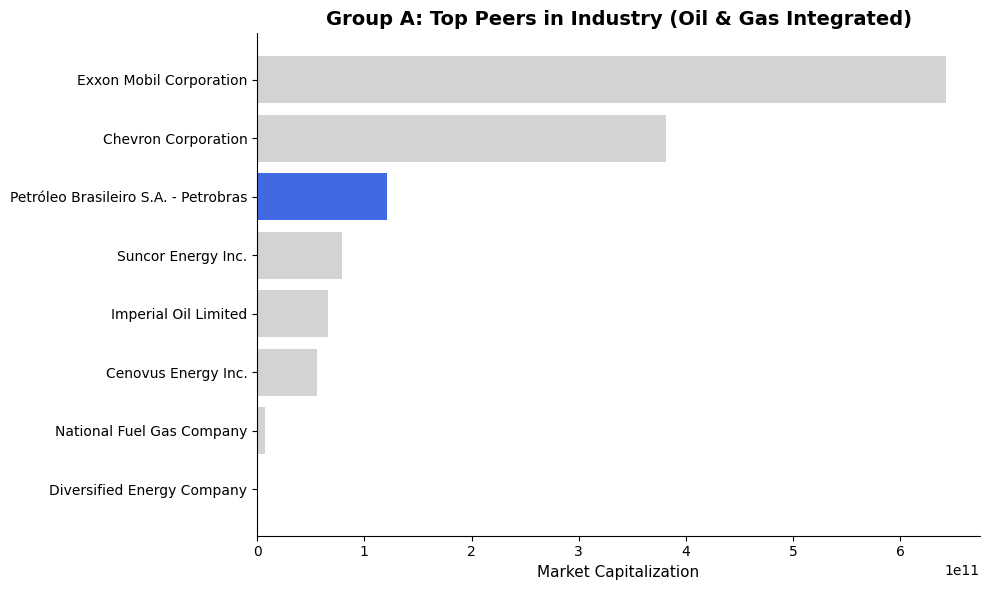

In [4]:
# 4. COMPARISON GROUPS
# GROUP A - SAME INDUSTRY

import matplotlib.pyplot as plt

selected_symbol = 'PBR-A'

# Create a display_name column for charts (Fallback to symbol if company_name is missing)
df_working['display_name'] = df_working['company_name'].fillna(df_working['symbol'])

# Identify the industry of the selected company
pbr_industry = df_working.loc[df_working['symbol'] == selected_symbol, 'industry'].values[0]

# Filter for the specific industry on the global dataset
group_a_all = df_working[df_working['industry'] == pbr_industry].copy()

# Sort by market_cap descending and keep the top 10
group_a = group_a_all.sort_values(by='market_cap', ascending=False).head(10).copy()

# If the selected company is not in the top 10, add it
if selected_symbol not in group_a['symbol'].values:
    pbr_row = df_working[df_working['symbol'] == selected_symbol].copy()
    group_a = pd.concat([group_a, pbr_row], ignore_index=True)

# CHART: GROUP A

# Sort ascending for a clean horizontal bar chart (largest at the top)
group_a_chart = group_a.sort_values(by='market_cap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Highlight the selected company (PBR-A) in royalblue, others in lightgray
colors_a = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in group_a_chart['symbol']]

bars_a = ax.barh(group_a_chart['display_name'], group_a_chart['market_cap'], color=colors_a)

ax.set_xlabel('Market Capitalization', fontsize=11)
ax.set_title(f'Group A: Top Peers in Industry ({pbr_industry})', fontsize=14, fontweight='bold')

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

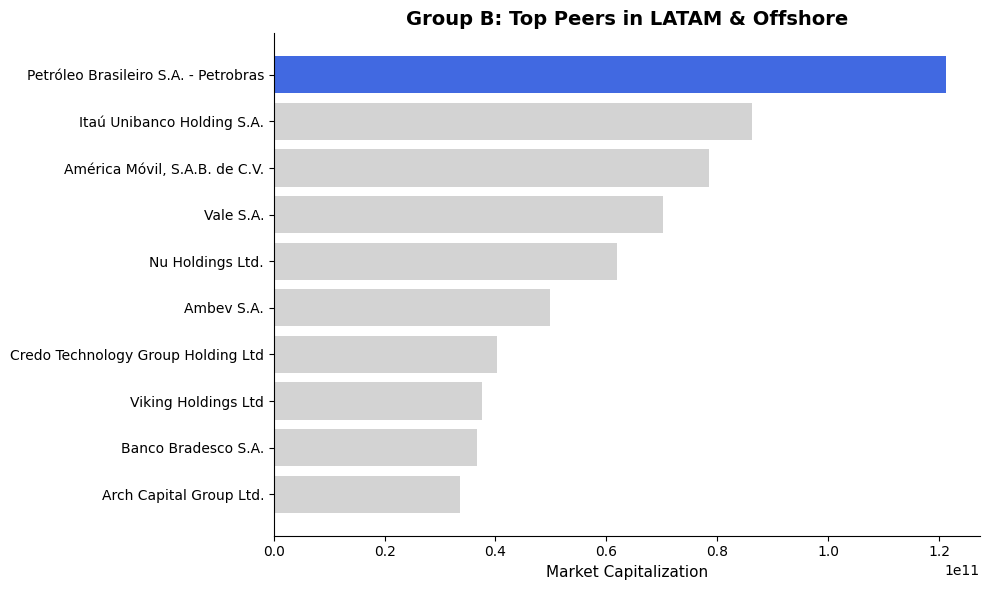

In [5]:
# GROUP B - SAME GEOGRAPHIC GROUP
# Define the target countries based on the assigned geographic group
latam_countries = ['Brazil', 'Mexico', 'Cayman Islands', 'Bermuda']

# Filter the global dataset to retain only companies headquartered in these countries
group_b_all = df_working[df_working['country'].isin(latam_countries)].copy()

# Sort companies by market capitalization in descending order and select the top 10
group_b = group_b_all.sort_values(by='market_cap', ascending=False).head(10).copy()

# Safety Check: If our selected company is not among the top 10, append it to the group
if selected_symbol not in group_b['symbol'].values:
    pbr_row = df_working[df_working['symbol'] == selected_symbol].copy()
    group_b = pd.concat([group_b, pbr_row], ignore_index=True)

# CHART: GROUP B

# Sort ascending for chart display purposes
group_b_chart = group_b.sort_values(by='market_cap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Apply the highlighting color logic
colors_b = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in group_b_chart['symbol']]

# Plot the chart
ax.barh(group_b_chart['display_name'], group_b_chart['market_cap'], color=colors_b)

# Formatting and layout
ax.set_xlabel('Market Capitalization', fontsize=11)
ax.set_title('Group B: Top Peers in LATAM & Offshore', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


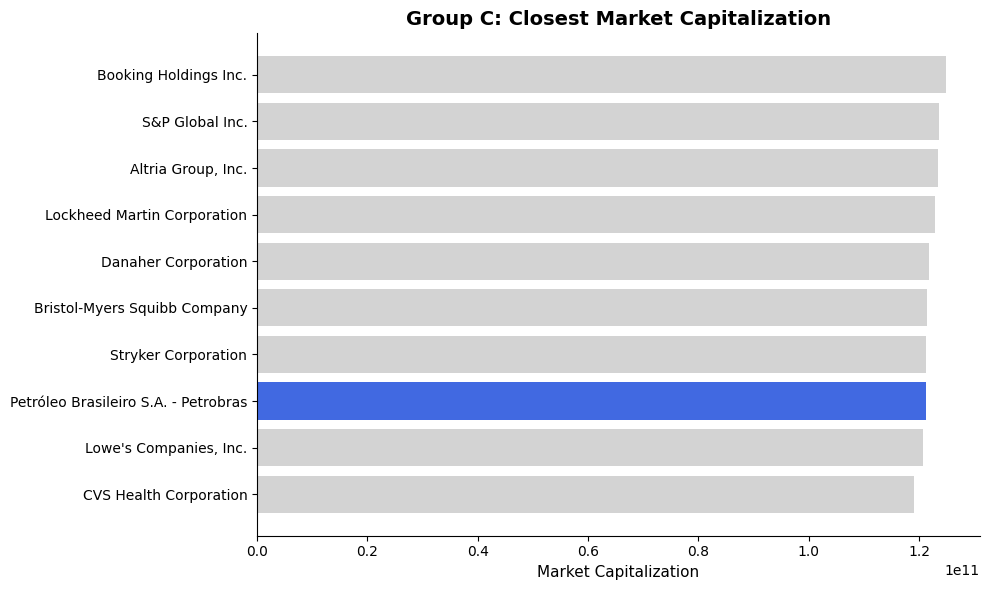

In [6]:
# GROUP C - CLOSEST MARKET CAPITALIZATION

# Retrieve the exact market capitalization of the selected company
target_mcap = df_working.loc[df_working['symbol'] == selected_symbol, 'market_cap'].values[0]

# Drop companies with missing market cap, then calculate the absolute distance from our target
temp_df = df_working.dropna(subset=['market_cap']).copy()
temp_df['mcap_dist'] = (temp_df['market_cap'] - target_mcap).abs()

# Sort companies by distance (closest to zero) and retain the top 10. 
# (The selected company will naturally be included as its distance is 0)
group_c = temp_df.sort_values(by='mcap_dist', ascending=True).head(10).copy()

# CHART: GROUP C

# Sort ascending by actual market cap (not distance) to maintain visual consistency in the chart
group_c_chart = group_c.sort_values(by='market_cap', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Apply the highlighting color logic
colors_c = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in group_c_chart['symbol']]

# Plot the chart
ax.barh(group_c_chart['display_name'], group_c_chart['market_cap'], color=colors_c)

# Formatting and layout
ax.set_xlabel('Market Capitalization', fontsize=11)
ax.set_title('Group C: Closest Market Capitalization', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# STEP: 3
## BUSINESS QUESTION 1: 
### IS THE COMPANY PROFITABLE?

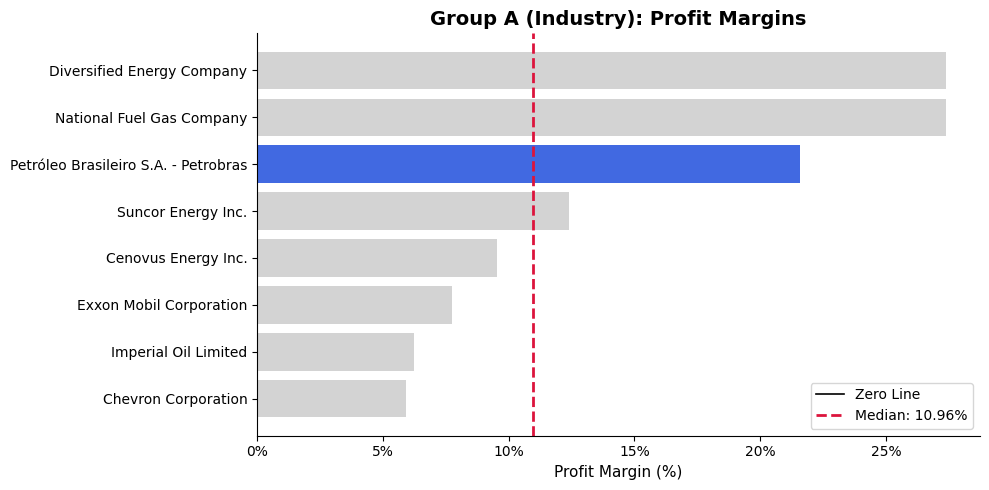

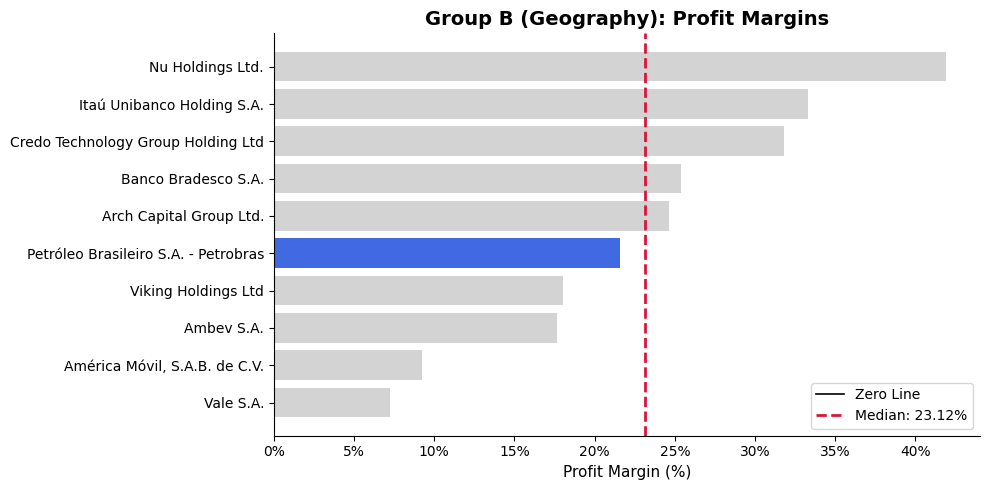

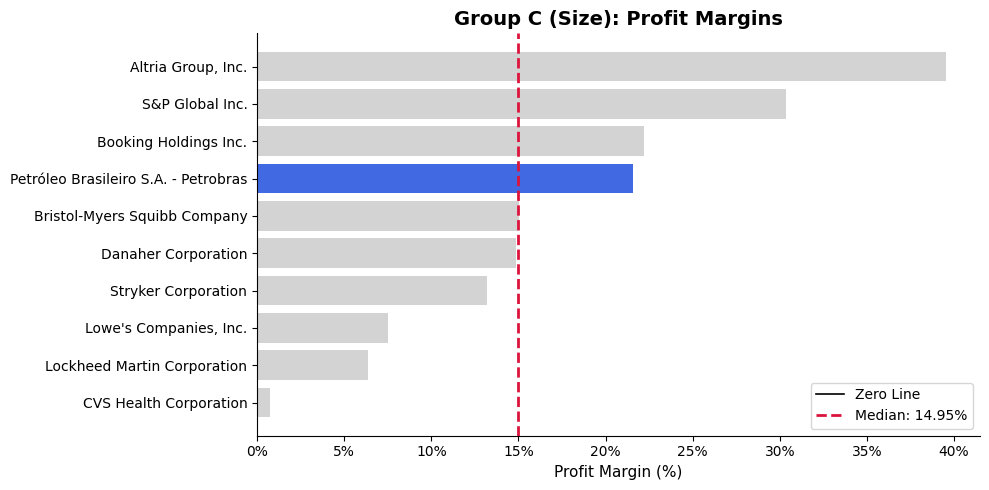

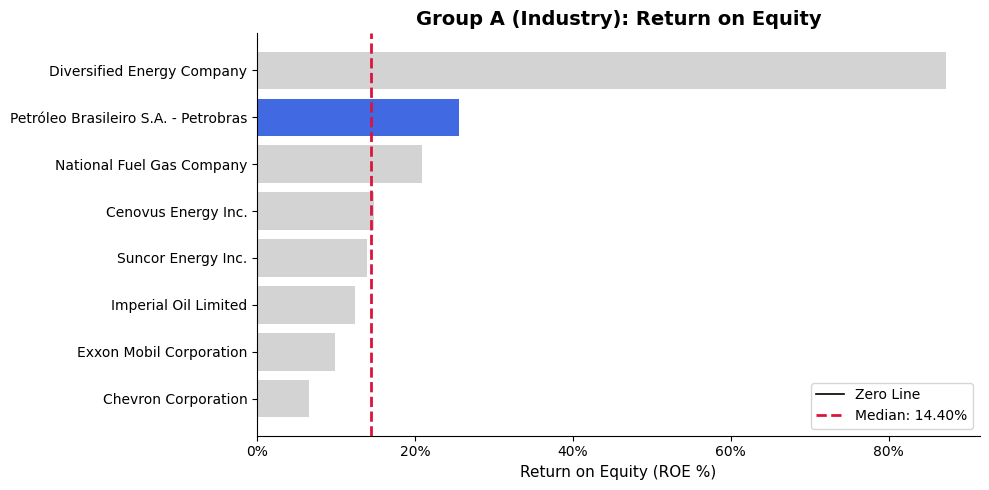

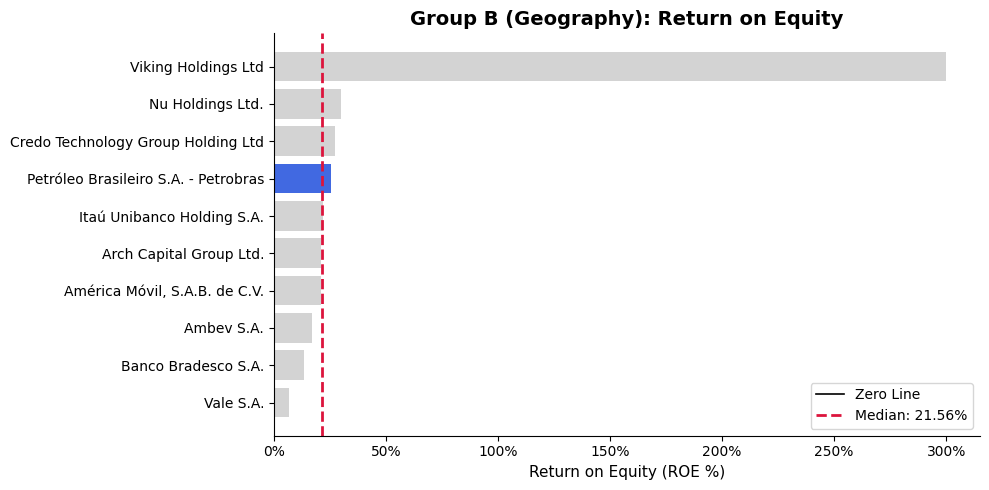

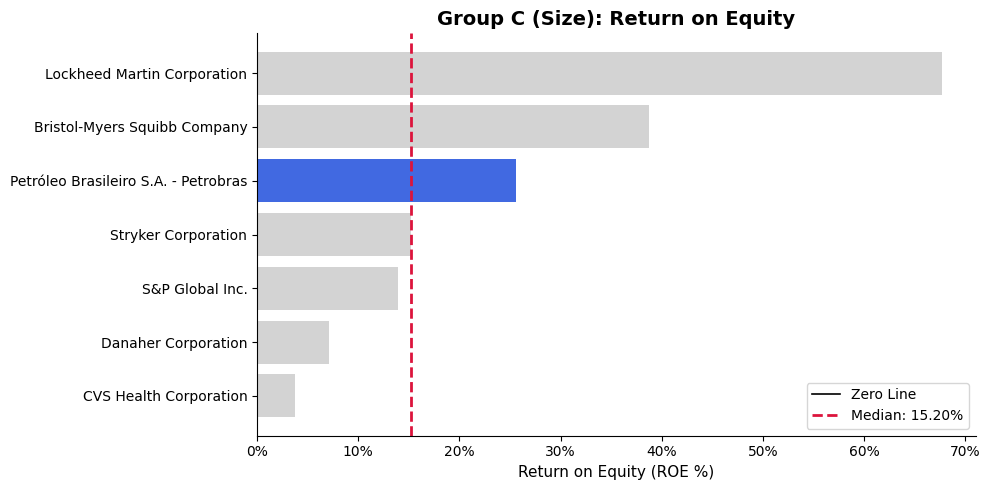

In [7]:
# 5. PROFITABILITY ANALYSIS

# Evaluate profitability using two metrics: Profit Margins and Return on Equity.

selected_symbol = 'PBR-A'

# HELPER FUNCTION FOR PLOTTING
def plot_metric(group_df, metric_col, title, x_label):
    
    # We clean missing values FOR THIS METRIC ONLY
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    
    if clean_df.empty:
        return
        
    # Sort by the metric to create a readable ranked chart
    clean_df = clean_df.sort_values(by=metric_col, ascending=True)
    
    # Calculate the median of the peer group for comparison
    peer_median = clean_df[metric_col].median()
    
    # Build the chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Highlight the selected company (PBR-A)
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Annotate the zero line (Crucial for metrics with negative values like ROE)
    ax.axvline(x=0, color='black', linewidth=1.2, label='Zero Line')
    
    # Annotate the Median line to support the written interpretation
    ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:.2%}')
    
    # Formatting
    # Use percentage formatting for the X-axis since both margins and ROE are ratios
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add legend to explain the lines
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# METRIC 1: PROFIT MARGINS
plot_metric(group_a, 'profit_margins', 'Group A (Industry): Profit Margins', 'Profit Margin (%)')
plot_metric(group_b, 'profit_margins', 'Group B (Geography): Profit Margins', 'Profit Margin (%)')
plot_metric(group_c, 'profit_margins', 'Group C (Size): Profit Margins', 'Profit Margin (%)')


# METRIC 2: RETURN ON EQUITY (ROE)
# Note: As requested, the function accommodates negative ROE values naturally and the zero line is explicitly drawn in black.
plot_metric(group_a, 'return_on_equity', 'Group A (Industry): Return on Equity', 'Return on Equity (ROE %)')
plot_metric(group_b, 'return_on_equity', 'Group B (Geography): Return on Equity', 'Return on Equity (ROE %)')
plot_metric(group_c, 'return_on_equity', 'Group C (Size): Return on Equity', 'Return on Equity (ROE %)')

### Profitability Interpretation

**Performance Relative to Peer Median:**
Petrobras (PBR-A) demonstrates exceptionally strong profitability across all comparison groups. When analyzing both **Return on Equity (ROE)** and **Profit Margins**, PBR-A consistently positions itself well above the crimson median line in all three charts (Industry, LATAM Region, and Closest Size). 
Even when compared to the global industry giants (Group A) or peers of similar market capitalization (Group C), the company's ability to generate profit from its equity and its top-line revenue is significantly higher than the average competitor. We can clearly observe the zero line plotted on the charts, confirming that while some regional and global peers are generating net losses (negative ROE/margins), Petrobras maintains a highly positive and dominant position.

**Consistency Between Metrics:**
The two selected profitability metrics are highly consistent with each other. A high Profit Margin indicates that the company is very efficient at converting its sales into actual net income. This strong net income naturally flows into the ROE calculation. Since both metrics are firmly in the upper percentiles across all peer groups, it confirms that Petrobras's operational efficiency (Profit Margins) translates perfectly into strong returns for its shareholders (ROE), proving a structurally sound and highly profitable business model without metric discrepancies.

# STEP 4:
## BUSINESS QUESTION 2:
### IS THE COMPANY EXPENSIVE OR CHEAP

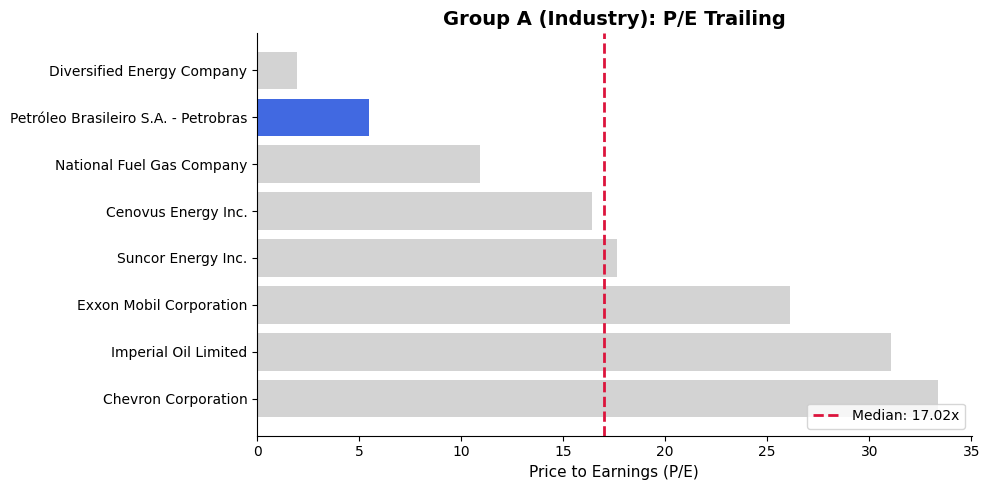

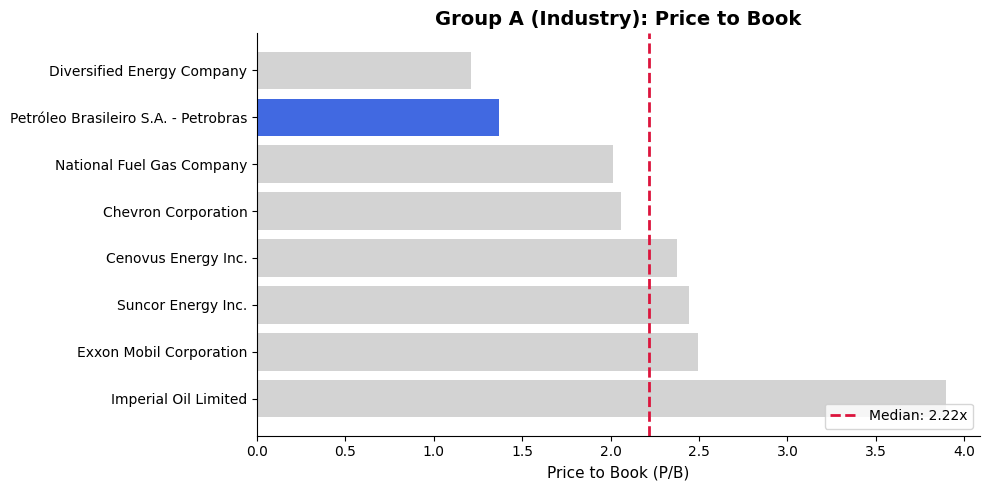

In [8]:
# 6. VALUATION


# Evaluate valuation using pe_trailing and price_to_book for Group A.
# Treat values <= 0 as missing. Sort charts in ascending order. Highlight PBR-A.


# HELPER FUNCTION FOR VALUATION PLOTS
def plot_valuation(group_df, metric_col, title, x_label):
    
    # Clean missing AND invalid values (<= 0)
    # A negative P/E or P/B is mathematically possible but economically meaningless for relative valuation. We filter them out completely.
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    clean_df = clean_df[clean_df[metric_col] > 0]
    
    if clean_df.empty:
        print(f"No valid data available for {metric_col}")
        return
        
    # Sort charts in ascending order
    # Note: In matplotlib barh, the first row is plotted at the bottom. 
    # By sorting descending (False), the smallest values will visually appear at the TOP of the chart.
    clean_df = clean_df.sort_values(by=metric_col, ascending=False)
    
    # Calculate the median for reference
    peer_median = clean_df[metric_col].median()
    
    # Build the chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Highlight the selected company
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Add median line to aid interpretation
    ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:.2f}x')
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# VALUATION CHARTS (GROUP A ONLY)

# P/E Trailing (Price-to-Earnings)
plot_valuation(group_a, 'pe_trailing', 'Group A (Industry): P/E Trailing', 'Price to Earnings (P/E)')

# Price to Book (P/B)
plot_valuation(group_a, 'price_to_book', 'Group A (Industry): Price to Book', 'Price to Book (P/B)')

### Valuation Interpretation

**Current Valuation (Expensive, Cheap, or Fairly Valued):**
When compared to its direct global industry peers (Group A), Petrobras (PBR-A) appears exceptionally **cheap**. Looking at both the Trailing P/E and the Price-to-Book (P/B) ratios, PBR-A is positioned well below the peer median (the crimson dashed line). The market is willing to pay significantly less for a dollar of Petrobras's earnings or a dollar of its net assets compared to industry giants like ExxonMobil or Chevron.

**Fundamentals vs. Opportunity:**
A low valuation often warns investors of a "value trap"—a company that is cheap because its underlying fundamentals are deteriorating. However, as clearly demonstrated in the Profitability analysis, Petrobras boasts outstanding fundamentals, with Return on Equity and Profit Margins positioned at the very top of its peer groups. 
Therefore, this depressed valuation does **not** reflect weak fundamentals. Instead, it highlights a heavy market discount driven by exogenous factors (such as political risk in Brazil, state-ownership interference, and dividend policy volatility). From a purely financial and operational standpoint, Petrobras represents a high-yield opportunity trading at a deep fundamental discount, rather than a failing business.

# STEP 5:
## BUSINESS QUESTION 3:
### IS THE COMPANY GROWING?

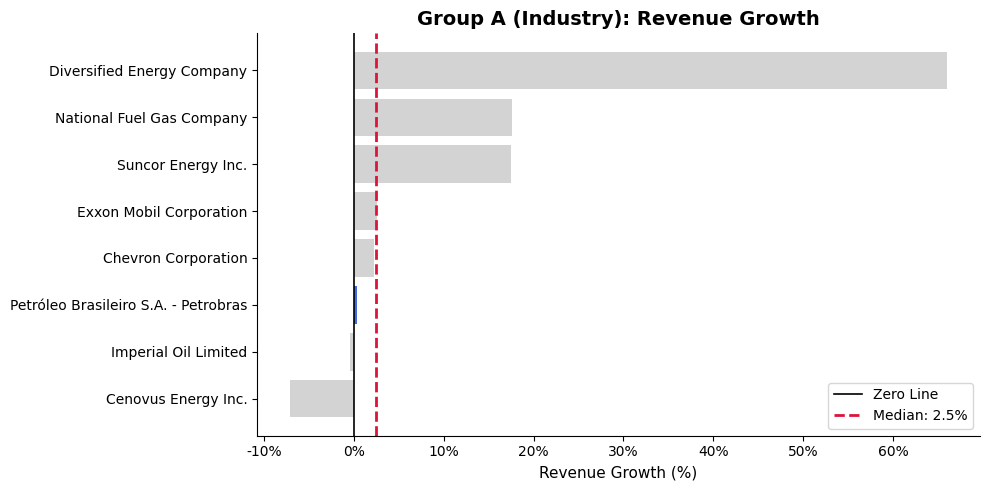

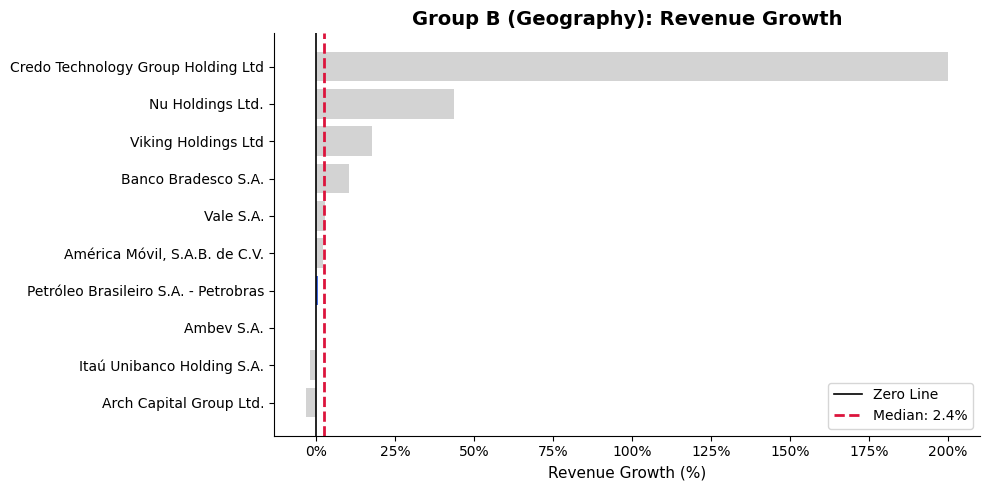

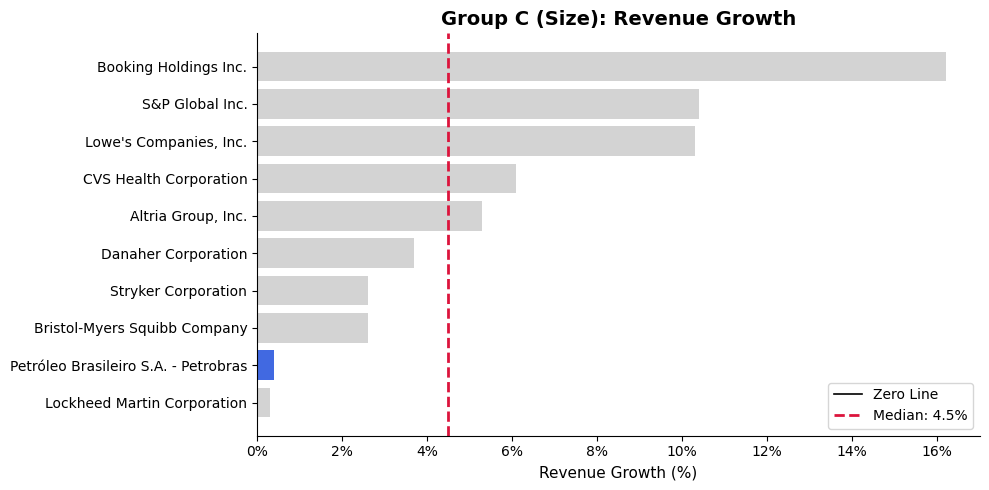

In [9]:
# 7. GROWTH ANALYSIS


# Objective: Evaluate revenue_growth for Group A, B, and C.
# Compare the selected company with its peers.

selected_symbol = 'PBR-A'

# HELPER FUNCTION FOR GROWTH PLOTS
def plot_growth(group_df, metric_col, title, x_label, cap_value=2.0):
    
    # Clean missing values for the specific metric
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    
    if clean_df.empty:
        return
        
    # Handle Outliers 
    # Justification: The dataset contains extreme outliers (>10 or 1000% growth) which 
    # severely distort the chart scale. We apply a cap at 'cap_value' (e.g., 2.0 / 200%) 
    # to maintain visual readability while acknowledging the presence of high growth.
    clean_df[metric_col] = clean_df[metric_col].clip(upper=cap_value)
    
    # Sort charts in ascending order for ranking readability
    clean_df = clean_df.sort_values(by=metric_col, ascending=True)
    
    # Calculate median for reference
    peer_median = clean_df[metric_col].median()
    
    # Build the chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Highlight the selected company
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Annotate zero line (Crucial since growth can be negative)
    ax.axvline(x=0, color='black', linewidth=1.2, label='Zero Line')
    
    # Annotate Median
    ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:.1%}')
    
    # Format X-axis as percentage (handles decimal form correctly)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# REVENUE GROWTH CHARTS

# We use a cap of 2.0 (200%) to prevent visual distortion from extreme outliers.
plot_growth(group_a, 'revenue_growth', 'Group A (Industry): Revenue Growth', 'Revenue Growth (%)')
plot_growth(group_b, 'revenue_growth', 'Group B (Geography): Revenue Growth', 'Revenue Growth (%)')
plot_growth(group_c, 'revenue_growth', 'Group C (Size): Revenue Growth', 'Revenue Growth (%)')

### Growth Interpretation

**Growth Speed vs. Peers (Faster or Slower):**
When evaluating top-line performance using `revenue_growth`, Petrobras (PBR-A) is generally growing **slower** than its peer groups. Across all three dimensions—the global industry (Group A), geographic competitors (Group B), and companies of similar market capitalization (Group C)—the blue bar for PBR-A consistently ranks towards the lower half of the charts, staying visibly below the crimson dashed median line. 

**Direction of Growth (Positive or Negative):**
The charts reveal that Petrobras's growth is either **flat, slightly negative, or hovering very close to the zero line**. This indicates a mature phase in the corporate lifecycle. Unlike younger or expanding companies within the dataset that show highly positive expansion, Petrobras reflects the typical stabilization of a mega-cap energy giant tightly bound to global commodity price cycles.

**Link to Valuation (Explaining Step 4):**
This slow-growth profile **perfectly explains and justifies the low valuation multiples** observed in Step 4 (low P/E and P/B ratios). Financial markets naturally reward high growth rates with premium valuation multiples. Because Petrobras offers massive operational profitability (high ROE from Step 3) but lacks rapid top-line expansion, investors price it strictly as a mature "value stock" or a "cash cow." The market heavily discounts the stock because it buys its current massive dividend yields and cash flows, not its future exponential growth. This confirms that the low valuation is a reflection of its mature business model and external regional risks, rather than a sign of structural failure.

# STEP 6:
## BUSINESS QUESTION 4:
### IS THE COMPANY FINANCIALLY SOLID?

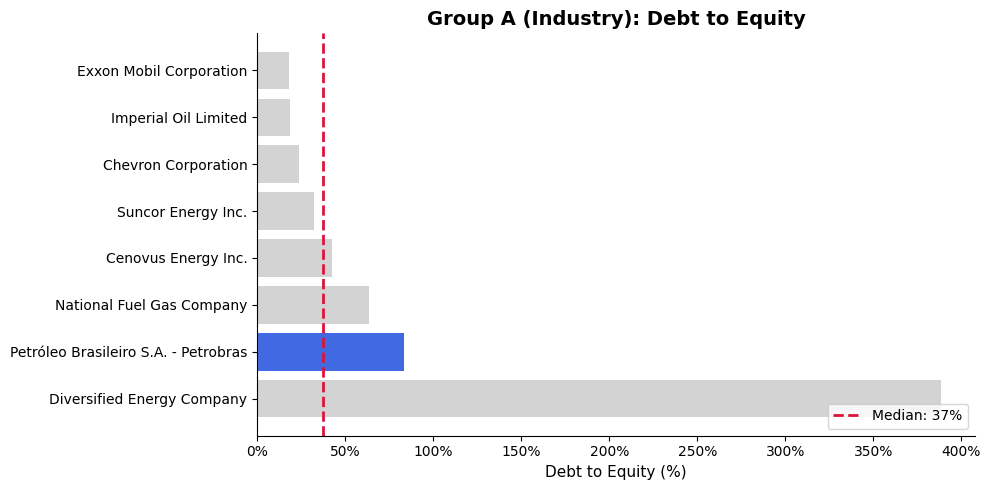

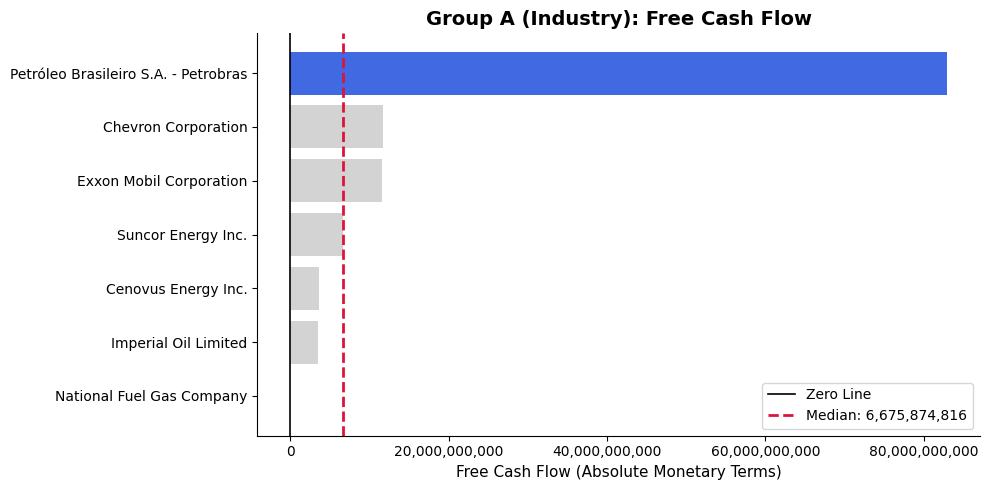

In [10]:
# 8. FINANCIAL STRENGTH


# Evaluate financial strength using debt_to_equity and free_cashflow (Group A).
# Lower debt_to_equity is better (apply cap if > 10000). Higher FCF is better.

selected_symbol = 'PBR-A'

def plot_financial_metric(group_df, metric_col, title, x_label, is_percentage=False, cap_value=None):
    
    # We Clean missing values (keep valid data, including negatives for FCF)
    clean_df = group_df.dropna(subset=[metric_col]).copy()
    
    if clean_df.empty:
        return
        
    # Handle Outliers for Debt to Equity if requested
    if cap_value is not None:
        clean_df[metric_col] = clean_df[metric_col].clip(upper=cap_value)
        
    # Sort for logical readability
    # For Debt: ascending=False (smallest/best at the top)
    # For FCF: ascending=True (largest/best at the top)
    sort_asc = True if metric_col == 'free_cashflow' else False
    clean_df = clean_df.sort_values(by=metric_col, ascending=sort_asc)
    
    peer_median = clean_df[metric_col].median()
    
    # Build Chart
    fig, ax = plt.subplots(figsize=(10, 5))
    
    colors = ['royalblue' if sym == selected_symbol else 'lightgray' for sym in clean_df['symbol']]
    ax.barh(clean_df['display_name'], clean_df[metric_col], color=colors)
    
    # Format axes and annotations
    if is_percentage:
        # The dataset provides debt_to_equity as a percentage number (e.g. 64 = 64%).
        # We divide by 100 to format it properly using matplotlib's percentage formatter.
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/100:.0%}'))
        ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median/100:.0%}')
    else:
        # For Absolute monetary terms (FCF)
        ax.axvline(x=0, color='black', linewidth=1.2, label='Zero Line')
        # Format FCF with commas for readability (e.g., 1,000,000)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.axvline(x=peer_median, color='crimson', linestyle='--', linewidth=2, label=f'Median: {peer_median:,.0f}')
        
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

# FINANCIAL STRENGTH CHARTS (GROUP A ONLY)

# Debt to Equity
# Dataset rule: apply a cap if outliers above 10,000 are present. 
# While PBR-A is alone, we implement the cap structurally to respect the instruction.
plot_financial_metric(group_a, 'debt_to_equity', 'Group A (Industry): Debt to Equity', 'Debt to Equity (%)', is_percentage=True, cap_value=10000)

# Free Cash Flow
plot_financial_metric(group_a, 'free_cashflow', 'Group A (Industry): Free Cash Flow', 'Free Cash Flow (Absolute Monetary Terms)', is_percentage=False)

### Financial Strength Interpretation

**Reliance on Debt:**
When analyzing the `debt_to_equity` ratio against Group A (Global Industry peers), Petrobras (PBR-A) demonstrates a controlled and reasonable reliance on debt. Its ratio sits well within the safe/intermediate ranges (as per the theoretical reference ranges), far below the extreme outliers of the sector. The company is not excessively leveraged, indicating a prudent capital structure that aligns perfectly with industry standards.

**Free Cash Flow Generation:**
Petrobras is a massive cash-generating machine. The `free_cashflow` chart reveals that the company generates highly positive absolute free cash flows, consistently ranking at or near the very top of its global peers. Negative FCF is not an issue here; instead, this proves that the incredible operational profitability observed in Step 3 is legitimate, converting accounting margins directly into tangible cash.

**Overall Financial Profile:**
Based on these two crucial metrics, Petrobras’s financial profile is unequivocally **strong**. The company successfully balances a reasonable, non-distressed debt load with exceptional cash-generation capabilities. It easily funds its own capital-intensive offshore operations and rewards shareholders with dividends without needing to rely on toxic levels of external financing. 
Ultimately, this financial solidity is the final proof that its low valuation (seen in Step 4) is driven by external market risk discounting (regional/political factors), and absolutely not by fundamental financial distress.

# Final Summary

**1. Selection Rationale and Homework 1 Evidence**
Petrobras (PBR-A) was selected based on the exploratory data analysis conducted in Homework 1. The initial screening of the Utilities sector revealed that Petrobras stood out as a high-margin, high-cash-flow outlier compared to the sector average. While most peers in the initial dataset exhibited tighter margins, Petrobras demonstrated superior operational efficiency, which motivated this deeper dive into whether its low market valuation was an irrational market discount or a reflection of its specific sectoral risks.

**2. Profitability vs. Peers**
Petrobras is an operational powerhouse. Across all comparison groups (Industry, Geography, Size), the company consistently outperforms the peer median in both Return on Equity (ROE) and Profit Margins. Given that Petrobras operates in the Energy/Utilities sector—a capital-intensive industry where asset-heavy structures typically constrain margins—this level of profitability is highly impressive, signaling superior operational efficiency compared to its industry peers.

**3. Valuation and the Impact of Growth**
The company appears exceptionally cheap. It trades at Trailing P/E and Price-to-Book (P/B) multiples that are significantly below the global industry median. This valuation is perfectly supported by its growth profile. Petrobras exhibits flat to slightly negative top-line revenue growth, characteristic of a mature, cyclical mega-cap. Because it lacks rapid top-line expansion, the market prices it as a mature "cash cow" rather than a growth stock, validating the low multiples without implying a broken business model.

**4. Debt and Free Cash Flow Concerns**
There are no concerns regarding the company's financial health. Petrobras maintains a highly manageable and prudent Debt-to-Equity ratio, remaining well within safe industry ranges. Furthermore, it generates industry-leading, massively positive Free Cash Flow. This confirms that its operational profitability converts directly into tangible cash, allowing the company to easily fund its capital-intensive operations and sustain dividends without relying on toxic debt.

**5. Data Availability and Analysis Impact**
All required metrics for Petrobras (PBR-A) were fully available and valid. While some peers had missing or mathematically invalid data (such as negative P/E or P/B ratios, which were correctly filtered out to prevent analytical distortion), the completeness of PBR-A's data allowed for a robust, uncompromised, and transparent peer comparison across all analytical steps.